# YOLO26 Vessel Detection Even Larger

Building on your best result: **imgsz=2560, mAP50=0.8791**

**This Notebook Tests:**
1. Even larger image size (3200) 
2. More epochs at 2560 (150, 200)

## 1. Setup

In [1]:
from ultralytics import YOLO
import torch
import time
import gc
import json
from datetime import datetime
from pathlib import Path

# Verify GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected!")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA B200
GPU Memory: 191.5 GB


In [2]:
# Paths
data_yaml_path = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo/data.yaml"
progress_file = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/push_limits_progress.json"

# Verify
if Path(data_yaml_path).exists():
    print(f"Data config found")
else:
    print(f"Data config NOT found: {data_yaml_path}")

Data config found


## 2. Helper Functions

In [3]:
def clear_memory():
    """Clear GPU and CPU memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def save_progress(results, filepath):
    """Save progress to JSON."""
    clean_results = []
    for r in results:
        clean_r = {}
        for k, v in r.items():
            if isinstance(v, (int, float, str, bool, type(None))):
                clean_r[k] = v
            else:
                clean_r[k] = str(v)
        clean_results.append(clean_r)
    
    with open(filepath, 'w') as f:
        json.dump(clean_results, f, indent=2)


def load_progress(filepath):
    """Load previous progress."""
    if Path(filepath).exists():
        with open(filepath, 'r') as f:
            return json.load(f)
    return []


def get_gpu_memory():
    """Get GPU memory usage."""
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        return f"{used:.1f}/{total:.1f} GB"
    return "N/A"

## 3. Define Experiments

In [4]:
# Base config
BASE_CONFIG = {
    'data': data_yaml_path,
    'rect': True,
    'device': 0,
    
    # Augmentations
    'mosaic': 0.5,
    'scale': 0.2,
    'fliplr': 0.5,
    'flipud': 0.0,
    
    # Training
    'patience': 30,
    'save': True,
    'plots': True,
    'project': 'jupiter_inlet_push_limits',
    'workers': 4,
}

In [5]:
# Experiments to run
experiments = [
    # ==========================================================================
    # OPTION 1: Even larger image size
    # ==========================================================================
    {
        'name': 'imgsz_3200_100ep',
        'model': 'yolo26s.pt',
        'imgsz': 3200,
        'batch': 1,  # Very small batch for huge images
        'epochs': 100,
    },
    
    # ==========================================================================
    # OPTION 2: More epochs at best image size (2560)
    # ==========================================================================
    {
        'name': 'imgsz_2560_150ep',
        'model': 'yolo26s.pt',
        'imgsz': 2560,
        'batch': 2,
        'epochs': 150,
    },
    {
        'name': 'imgsz_2560_200ep',
        'model': 'yolo26s.pt',
        'imgsz': 2560,
        'batch': 2,
        'epochs': 200,
    },
]

print(f"Experiments to run: {len(experiments)}")
for i, exp in enumerate(experiments, 1):
    print(f"  {i}. {exp['name']}: imgsz={exp['imgsz']}, epochs={exp['epochs']}, batch={exp['batch']}")

Experiments to run: 3
  1. imgsz_3200_100ep: imgsz=3200, epochs=100, batch=1
  2. imgsz_2560_150ep: imgsz=2560, epochs=150, batch=2
  3. imgsz_2560_200ep: imgsz=2560, epochs=200, batch=2


## 4. Check for Previous Progress

In [6]:
# Load previous progress
previous_results = load_progress(progress_file)

if previous_results:
    completed = [r['experiment'] for r in previous_results if r.get('status') == 'success']
    print(f"Found {len(completed)} completed experiments:")
    for name in completed:
        print(f"{name}")
    
    results_summary = previous_results
else:
    results_summary = []
    completed = []
    print("No previous progress found. Starting fresh.")

# Filter to remaining experiments
experiments_to_run = [exp for exp in experiments if exp['name'] not in completed]

print(f"\nWill run {len(experiments_to_run)} experiment(s):")
for exp in experiments_to_run:
    print(f"  - {exp['name']}")

Found 3 completed experiments:
imgsz_3200_100ep
imgsz_2560_150ep
imgsz_2560_200ep

Will run 0 experiment(s):


## 5. Run Experiments

In [7]:
# Your previous best for comparison
PREVIOUS_BEST = {
    'experiment': 'large_imgsz_2560 (previous best)',
    'mAP50': 0.8791,
    'imgsz': 2560,
    'epochs': 100
}
print(f"Target to beat: mAP50 = {PREVIOUS_BEST['mAP50']}")

Target to beat: mAP50 = 0.8791


In [9]:
total_start = time.time()

print(f"Starting at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"GPU Memory: {get_gpu_memory()}")
print("=" * 70)

for i, exp in enumerate(experiments_to_run, 1):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT {i}/{len(experiments_to_run)}: {exp['name']}")
    print(f"Config: imgsz={exp['imgsz']}, epochs={exp['epochs']}, batch={exp['batch']}")
    print(f"GPU Memory: {get_gpu_memory()}")
    print(f"{'='*70}\n")
    
    # Clear memory
    clear_memory()
    
    # Build config
    config = BASE_CONFIG.copy()
    config['imgsz'] = exp['imgsz']
    config['batch'] = exp['batch']
    config['epochs'] = exp['epochs']
    config['name'] = exp['name']
    
    exp_start = time.time()
    model = None
    
    try:
        print(f"Loading {exp['model']}...")
        model = YOLO(exp['model'])
        
        print(f"Training...")
        results = model.train(**config)
        
        train_time = time.time() - exp_start
        
        # Extract metrics
        metrics = results.results_dict
        mAP50 = metrics.get('metrics/mAP50(B)', None)
        recall = metrics.get('metrics/recall(B)', None)
        precision = metrics.get('metrics/precision(B)', None)
        best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
        
        result_entry = {
            'experiment': exp['name'],
            'model': exp['model'],
            'imgsz': exp['imgsz'],
            'epochs': exp['epochs'],
            'batch': exp['batch'],
            'mAP50': mAP50,
            'mAP50-95': metrics.get('metrics/mAP50-95(B)', None),
            'precision': precision,
            'recall': recall,
            'training_time_min': round(train_time / 60, 1),
            'best_model_path': str(best_model_path),
            'status': 'success'
        }
        
        # Compare to previous best
        improvement = mAP50 - PREVIOUS_BEST['mAP50'] if mAP50 else 0
        
        print(f"Completed in {train_time/60:.1f} min")
        print(f"   mAP50: {mAP50:.4f}")
        print(f"   Recall: {recall:.4f}")
        print(f"   Precision: {precision:.4f}")
        
        if improvement > 0:
            print(f" NEW BEST! +{improvement:.4f} improvement over previous best!")
        else:
            print(f" Compared to previous best: {improvement:+.4f}")
        
        # Clean up
        del model
        del results
        model = None
        clear_memory()
        
    except Exception as e:
        exp_time = time.time() - exp_start
        print(f"FAILED after {exp_time/60:.1f} min")
        print(f"   Error: {str(e)}")
        
        result_entry = {
            'experiment': exp['name'],
            'model': exp['model'],
            'imgsz': exp['imgsz'],
            'epochs': exp['epochs'],
            'batch': exp['batch'],
            'mAP50': None,
            'recall': None,
            'precision': None,
            'training_time_min': round(exp_time / 60, 1),
            'status': f'failed: {str(e)[:100]}'
        }
    
    finally:
        if model is not None:
            del model
        clear_memory()
    
    # Save progress
    results_summary.append(result_entry)
    save_progress(results_summary, progress_file)
    print(f"   Progress saved.")

total_time = time.time() - total_start
print(f"\n{'='*70}")
print(f"ALL EXPERIMENTS COMPLETED")
print(f"Total time: {total_time/60:.1f} min ({total_time/3600:.1f} hours)")
print(f"{'='*70}")

Starting at 2026-02-12 09:12:27
GPU Memory: 0.0/191.5 GB

ALL EXPERIMENTS COMPLETED
Total time: 0.0 min (0.0 hours)


## 6. Results Summary

In [10]:
# Add previous best for comparison
all_results = results_summary + [{
    'experiment': 'previous_best_2560_100ep',
    'imgsz': 2560,
    'epochs': 100,
    'mAP50': 0.8791,
    'status': 'success',
    'note': 'Previous best for comparison'
}]

# Filter successful
successful = [r for r in all_results if r.get('status') == 'success' and r.get('mAP50')]

# Sort by mAP50
sorted_results = sorted(successful, key=lambda x: x.get('mAP50', 0), reverse=True)

In [13]:
print("="*80)
print("RESULTS COMPARISON")
print("="*80)
print(f"{'Rank':<5} {'Experiment':<30} {'ImgSz':<7} {'Epochs':<7} {'mAP50':<10} {'vs Best':<10}")
print("-"*80)

for rank, r in enumerate(sorted_results, 1):
    mAP = r.get('mAP50', 0)
    diff = mAP - PREVIOUS_BEST['mAP50']
    diff_str = f"{diff:+.4f}" if diff != 0 else "baseline"
    
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    
    print(f"{medal}{rank:<3} {r['experiment']:<30} {r.get('imgsz', 'N/A'):<7} {r.get('epochs', 'N/A'):<7} {mAP:<10.4f} {diff_str:<10}")

RESULTS COMPARISON
Rank  Experiment                     ImgSz   Epochs  mAP50      vs Best   
--------------------------------------------------------------------------------
🥇1   previous_best_2560_100ep       2560    100     0.8791     baseline  
🥈2   imgsz_2560_150ep               2560    150     0.8767     -0.0024   
🥉3   imgsz_2560_200ep               2560    200     0.8188     -0.0603   
  4   imgsz_3200_100ep               3200    100     0.7733     -0.1058   


In [14]:
# Best result
if sorted_results:
    best = sorted_results[0]
    
    print("\n" + "="*60)
    print("BEST RESULT")
    print("="*60)
    print(f"\nExperiment: {best['experiment']}")
    print(f"mAP50: {best['mAP50']:.4f}")
    print(f"Config: imgsz={best.get('imgsz')}, epochs={best.get('epochs')}")
    
    if best.get('recall'):
        print(f"Recall: {best['recall']:.4f}")
    if best.get('precision'):
        print(f"Precision: {best['precision']:.4f}")
    
    improvement = best['mAP50'] - PREVIOUS_BEST['mAP50']
    if improvement > 0:
        print(f"NEW RECORD! +{improvement:.4f} over previous best!")
    elif improvement == 0:
        print(f"Matches previous best")
    else:
        print(f"Previous best (2560, 100ep) still leads by {-improvement:.4f}")
    
    if best.get('best_model_path'):
        print(f"Best model saved at:")
        print(f"   {best['best_model_path']}")


BEST RESULT

Experiment: previous_best_2560_100ep
mAP50: 0.8791
Config: imgsz=2560, epochs=100
Matches previous best


## 7. Visualization

In [16]:
import matplotlib.pyplot as plt
import numpy as np

output_dir = Path('jupiter_inlet_push_limits')
output_dir.mkdir(exist_ok=True)

Saved: jupiter_inlet_push_limits/results_comparison.png


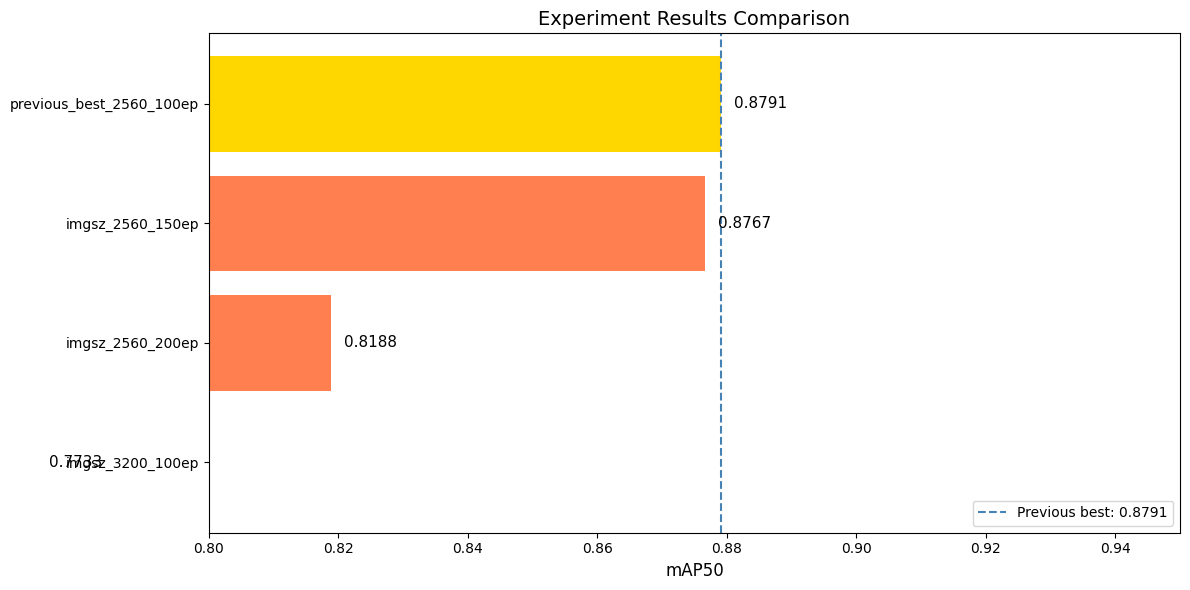

In [17]:
# Plot: All results comparison
if sorted_results:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    names = [r['experiment'][:25] for r in sorted_results]
    mAPs = [r['mAP50'] for r in sorted_results]
    
    # Color: gold for best, coral for new experiments, steelblue for previous
    colors = []
    for i, r in enumerate(sorted_results):
        if i == 0:
            colors.append('gold')
        elif 'previous' in r['experiment']:
            colors.append('steelblue')
        else:
            colors.append('coral')
    
    bars = ax.barh(range(len(names)), mAPs, color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    ax.set_xlabel('mAP50', fontsize=12)
    ax.set_title('Experiment Results Comparison', fontsize=14)
    ax.set_xlim(0.8, 0.95)  # Zoom in on relevant range
    ax.invert_yaxis()
    
    # Value labels
    for i, v in enumerate(mAPs):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=11)
    
    # Reference line for previous best
    ax.axvline(x=PREVIOUS_BEST['mAP50'], color='steelblue', linestyle='--', 
               label=f"Previous best: {PREVIOUS_BEST['mAP50']:.4f}")
    ax.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'results_comparison.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {output_dir / 'results_comparison.png'}")
    plt.show()

Saved: jupiter_inlet_push_limits/epochs_vs_performance_2560.png


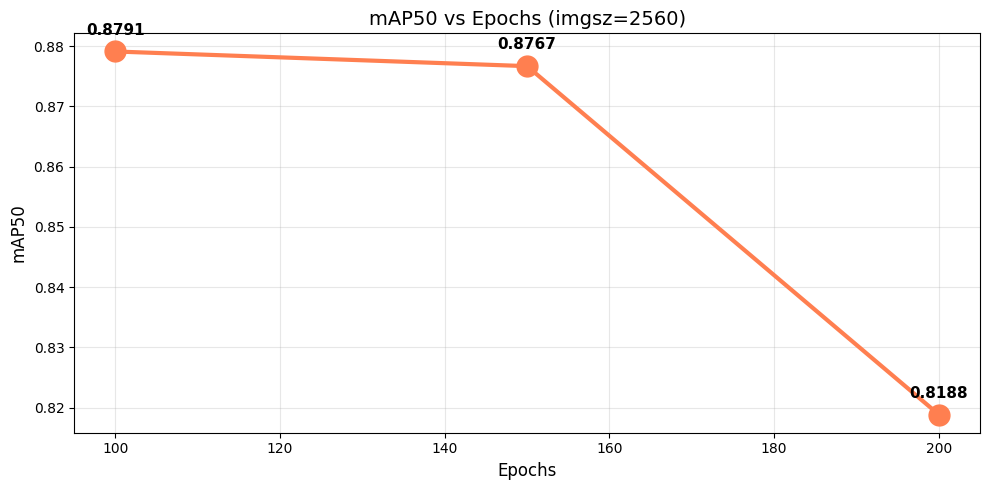

In [18]:
# Plot: Epochs vs Performance (for 2560 experiments)
epoch_results = [r for r in successful if r.get('imgsz') == 2560]

if len(epoch_results) > 1:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    epoch_results_sorted = sorted(epoch_results, key=lambda x: x.get('epochs', 0))
    
    epochs = [r['epochs'] for r in epoch_results_sorted]
    mAPs = [r['mAP50'] for r in epoch_results_sorted]
    
    ax.plot(epochs, mAPs, 'o-', color='coral', markersize=15, linewidth=3)
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('mAP50', fontsize=12)
    ax.set_title('mAP50 vs Epochs (imgsz=2560)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Annotate points
    for e, m in zip(epochs, mAPs):
        ax.annotate(f'{m:.4f}', (e, m), textcoords="offset points", xytext=(0, 12), 
                   ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'epochs_vs_performance_2560.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {output_dir / 'epochs_vs_performance_2560.png'}")
    plt.show()

Saved: jupiter_inlet_push_limits/imgsz_vs_performance.png


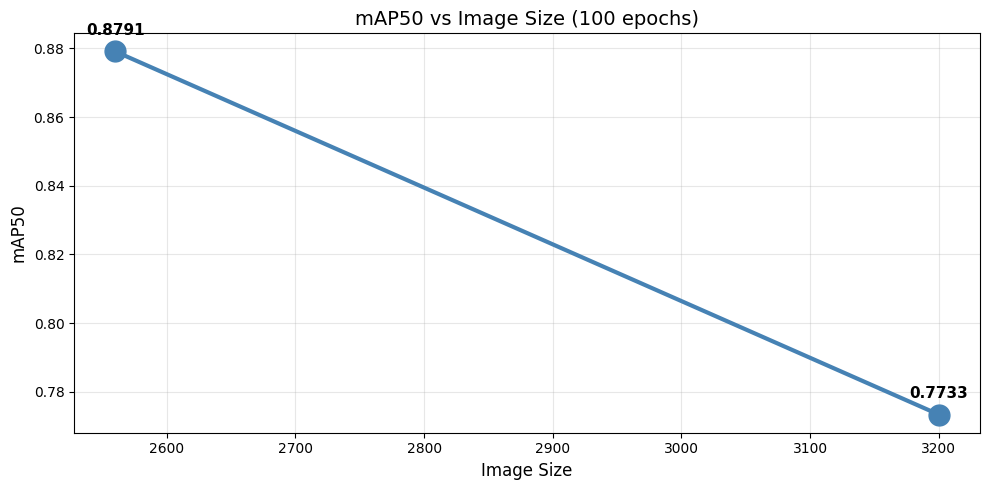

In [19]:
# Plot: Image Size vs Performance
imgsz_results = [r for r in successful if r.get('epochs') == 100]  # Control for epochs

if len(imgsz_results) > 1:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    imgsz_sorted = sorted(imgsz_results, key=lambda x: x.get('imgsz', 0))
    
    sizes = [r['imgsz'] for r in imgsz_sorted]
    mAPs = [r['mAP50'] for r in imgsz_sorted]
    
    ax.plot(sizes, mAPs, 'o-', color='steelblue', markersize=15, linewidth=3)
    ax.set_xlabel('Image Size', fontsize=12)
    ax.set_ylabel('mAP50', fontsize=12)
    ax.set_title('mAP50 vs Image Size (100 epochs)', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Annotate
    for s, m in zip(sizes, mAPs):
        ax.annotate(f'{m:.4f}', (s, m), textcoords="offset points", xytext=(0, 12),
                   ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'imgsz_vs_performance.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {output_dir / 'imgsz_vs_performance.png'}")
    plt.show()